A Stationary series is one whose statistical properties such as mean,variance,covariance and standard deviation do not vary with time or these stats properties are not a function of time.In other words,stationarity in Time Series also means without a **Trend** or **Seasonal** components.

- Constant mean
- Constant Variance
- Constant covariance

# 👀 Visual Signs of Non-Stationarity

A time series is said to be **non-stationary** when its statistical properties change over time.

---

## 🔍 Key Indicators

### 🔹 Trend
- A clear **upward or downward movement** over time  
- Indicates that the **mean is not constant**  

📈 Upward trend → Increasing values  
📉 Downward trend → Decreasing values  

---

### 🔹 Seasonality
- A **pattern that repeats at regular intervals**  
- Can occur **yearly, monthly, or weekly**  

🔁 Example: Sales increasing during festive seasons  

---

### 🔹 Varying Variance
- The **spread of data points changes over time**  
- The series may appear **wider or narrower**  

📊 Indicates increasing or decreasing fluctuations  


# 📊 Stationarity Tests

## 🔹 ADF Test (Augmented Dickey-Fuller)

- **Null Hypothesis (H₀):** Series is **non-stationary**  
- **Alternative Hypothesis (H₁):** Series is **stationary**  

### 📌 Decision Rule:
- If **p-value < 0.05** → Reject H₀ → ✅ Series is **stationary**  
- If **p-value ≥ 0.05** → Fail to reject H₀ → ❌ Series is **non-stationary**  

---

## 🔹 KPSS Test (Kwiatkowski-Phillips-Schmidt-Shin)

- **Null Hypothesis (H₀):** Series is **stationary (trend stationary)**  
- **Alternative Hypothesis (H₁):** Series is **non-stationary**  

### 📌 Decision Rule:
- If **p-value < 0.05** → Reject H₀ → ❌ Series is **non-stationary**  
- If **p-value ≥ 0.05** → Fail to reject H₀ → ✅ Series is **stationary**  

---

## ⚖️ Key Difference

| Test | Null Hypothesis | Use |
|------|----------------|-----|
| ADF  | Non-stationary | Confirms stationarity |
| KPSS | Stationary     | Confirms non-stationarity |



In [1]:
# Load the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Using airline passengers dataset (monthly totals)
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month' )
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


<Axes: xlabel='Month'>

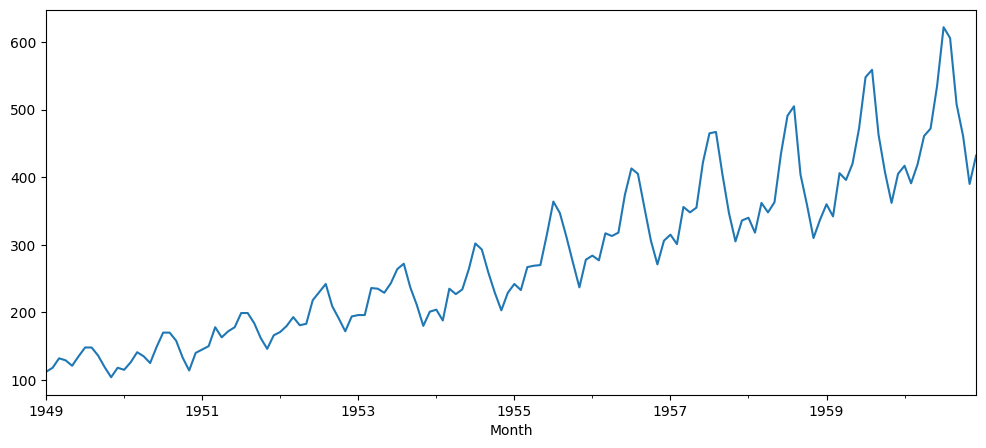

In [3]:
df["Passengers"].plot(figsize=(12, 5))

In [4]:
from statsmodels.tsa.stattools import adfuller

In [5]:
dftest = adfuller(df['Passengers'], autolag='AIC')

In [6]:
dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
for key, value in dftest[4].items():
    dfoutput['Critical Value (%s)' % key] = value
dfoutput

,0
Test Statistic,0.815369
p-value,0.991880
#Lags Used,13.000000
Number of Observations Used,130.000000
Critical Value (1%),-3.481682
Critical Value (5%),-2.884042
Critical Value (10%),-2.578770


In [7]:
from statsmodels.tsa.stattools import kpss

In [8]:
kpsstest = kpss(df['Passengers'], regression='c', nlags='auto')

/tmp/ipykernel_8850/1195507731.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpsstest = kpss(df['Passengers'], regression='c', nlags='auto')


In [9]:
kpss_output = pd.Series(kpsstest[0:3], index=['Test Statistic', 'p-value', 'Lags Used'])
for key, value in kpsstest[3].items():
    kpss_output['Critical Value (%s)' % key] = value
kpss_output

,0
Test Statistic,1.651312
p-value,0.010000
Lags Used,8.000000
Critical Value (10%),0.347000
Critical Value (5%),0.463000
Critical Value (2.5%),0.574000
Critical Value (1%),0.739000


In [10]:
def kpss_test(timeseries):
  print('Results of KPSS Test:')
  kpsstest = pd.series(kpsstest[0:3], index=['Test Statistic', 'p-value', 'Lags Used'])
  for key, value in kpsstest[3].items():
    kpss_output['Critical Value (%s)' % key] = value
  print(kpss_output)

The following are the possible outcomes of applying both tests.

- **Case 1:** Both tests conclude that the given series is stationary − The series is stationary
- **Case 2:** Both tests conclude that the given series is non-stationary − The series is non-stationary
- **Case 3:** ADF concludes non-stationary, and KPSS concludes stationary − The series is **trend stationary**. To make the series strictly stationary, we need to remove the trend in this case. Then we check the detrended series for stationarity.
- **Case 4:** ADF concludes stationary, and KPSS concludes non-stationary − The series is **difference stationary**. Differencing is to be used to make series stationary. Then we check the differenced series for stationarity.



In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller,kpss
from sklearn.linear_model import LinearRegression

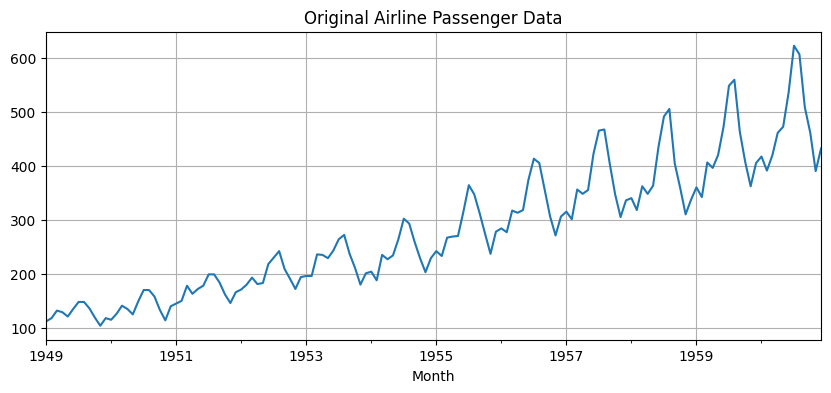

In [12]:
# Plot original series
df['Passengers'].plot(title='Original Airline Passenger Data', figsize =(10,4))
plt.grid()
plt.show()

In [14]:
# Step 1 : Fit linear regression(trend) using sklearn
X = np.arange(len(df)).reshape(-1,1)       # Time as feature
y = df['Passengers'].values                 # Passenger values
model = LinearRegression().fit(X,y)
trend = model.predict(X)                    # Predict

In [15]:
df['detrended'] = y - model.predict(X)

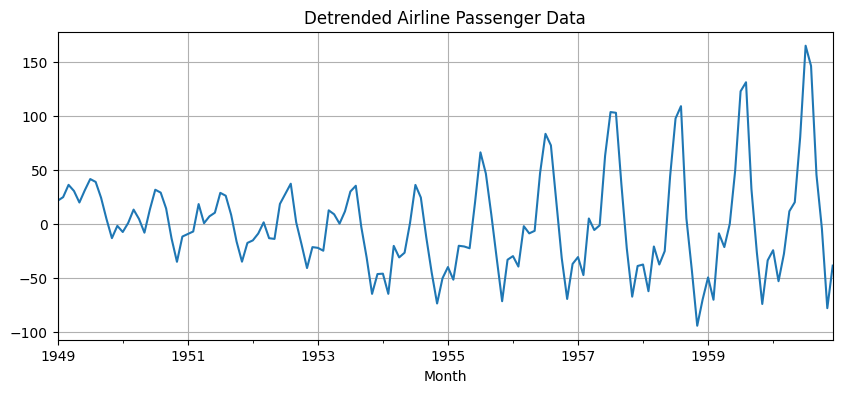

In [16]:
# Plot detrended series
df['detrended'].plot(title='Detrended Airline Passenger Data', figsize =(10,4))
plt.grid()
plt.show()

In [17]:
# Step 2: Stationarity Tests
# ADF Test
adf_orig_p = adfuller(df['Passengers'])[1]
adf_det_p = adfuller(df['detrended'])[1]

# KPSS Test
kpss_orig_p = kpss(df['Passengers'], regression='ct')[1]   # trend + constant
kpss_det_p = kpss(df['detrended'], regression='c')[1]      # constant only

# Step 3: Print Results
print("📊 Stationarity Test Results")
print(f"ADF (Original):    p = {adf_orig_p:.4f} → {'Non-stationary' if adf_orig_p > 0.05 else 'Stationary'}")
print(f"KPSS (Original):   p = {kpss_orig_p:.4f} → {'Non-stationary' if kpss_orig_p < 0.05 else 'Stationary'}")
print(f"ADF (Detrended):   p = {adf_det_p:.4f} → {'Non-stationary' if adf_det_p > 0.05 else 'Stationary'}")
print(f"KPSS (Detrended):  p = {kpss_det_p:.4f} → {'Non-stationary' if kpss_det_p < 0.05 else 'Stationary'}")

📊 Stationarity Test Results
ADF (Original):    p = 0.9919 → Non-stationary
KPSS (Original):   p = 0.1000 → Stationary
ADF (Detrended):   p = 0.2437 → Non-stationary
KPSS (Detrended):  p = 0.1000 → Stationary


/tmp/ipykernel_8850/269805991.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_orig_p = kpss(df['Passengers'], regression='ct')[1]   # trend + constant
/tmp/ipykernel_8850/269805991.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_det_p = kpss(df['detrended'], regression='c')[1]      # constant only
